# Overview

A pioneering coffee shop in Los Angeles, known for its innovative robotic service, is seeking strategic investment to scale operations. However, the hospitality market is volatile, and the "novelty factor" of robots may diminish over time.

### Business Problem

The core challenge is to determine if the business model remains sustainable based on current market trends. To provide a data-backed recommendation for investors, this project analyzes the competitive landscape of the LA restaurant industry.

### Data Description

The analysis is based on open-source data regarding restaurants in Los Angeles.

| Column | Description |
| :--- | :--- |
| `object_name` | Name of the establishment |
| `chain` | Boolean indicating if the establishment belongs to a chain |
| `object_type` | Category of the establishment (e.g., Cafe, Fast Food, Restaurant) |
| `address` | Full physical address |
| `number` | Number of seats (capacity) |

---

### **1. Data Loading & Initial Exploration**

First, we load the dataset and perform a preliminary inspection to understand the structure of the data and identify any immediate issues with data types or missing values.

In [24]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import ticker

In [19]:
# Loading the dataset
rest_data = pd.read_csv('../data/rest_data_us_upd.csv')

# Visual inspection of the first few rows
display(rest_data.head())
print()
# Technical summary of the dataframe
rest_data.info()

,id,object_name,address,chain,object_type,number
0,11786,HABITAT COFFEE SHOP,3708 N EAGLE ROCK BLVD,False,Cafe,26
1,11787,REILLY'S,100 WORLD WAY 120,False,Restaurant,9
2,11788,STREET CHURROS,6801 HOLLYWOOD BLVD 253,False,Fast Food,20
3,11789,TRINITI ECHO PARK,1814 W SUNSET BLVD,False,Restaurant,22
4,11790,POLLEN,2100 ECHO PARK AVE,False,Restaurant,20



<class 'pandas.DataFrame'>
RangeIndex: 9651 entries, 0 to 9650
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id           9651 non-null   int64 
 1   object_name  9651 non-null   str   
 2   address      9651 non-null   str   
 3   chain        9648 non-null   object
 4   object_type  9651 non-null   str   
 5   number       9651 non-null   int64 
dtypes: int64(2), object(1), str(3)
memory usage: 452.5+ KB


### **2. Handling Missing Values**

Upon investigation, a small inconsistency was found in the chain column.

In [21]:
# Checking for null values

null_count = rest_data['chain'].isnull().sum()
print(f"Total null values in 'chain': {null_count}")

Total null values in 'chain': 3


As identified, there are only 3 missing values out of 9,561 records (approximately 0.03% of the dataset).

In [23]:
# Inspecting the rows with missing values

rest_data[rest_data['chain'].isnull()]

,id,object_name,address,chain,object_type,number
7408,19194,TAQUERIA LOS 3 CARNALES,5000 E WHITTIER BLVD,NaN,Restaurant,14
7523,19309,JAMMIN JIMMY'S PIZZA,1641 FIRESTONE BLVD,NaN,Pizza,1
8648,20434,THE LEXINGTON THEATER,129 E 3RD ST,NaN,Restaurant,35


Note: Given that these 3 rows represent a negligible fraction of the total data, they will be removed during the data cleaning phase to ensure a robust analysis without introducing bias.

In [25]:
rest_data.dropna(subset=['chain'], inplace=True)

### **3. Data Integrity: Duplicates Check**

Before proceeding to analysis, it is crucial to verify if the dataset contains any redundant information. Duplicate entries can skew statistical results and lead to misleading conclusions.

In [26]:
# Checking for duplicated rows
duplicate_count = rest_data.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

Number of duplicate rows: 0


**Findings:**

No duplicate records were found within the dataset. This confirms that each entry represents a unique observation, ensuring the reliability of our subsequent analysis.

## **4. Data Analysis & Visualization**

### 4.1. Distribution of Establishment Types
We begin by analyzing the prevalence of different establishment types. This helps identify the dominant market segments in our dataset.

In [27]:
top_rest_type = rest_data['object_type'].value_counts().reset_index()
top_rest_type.columns = ['type','establishment_count']


display(top_rest_type)

,type,establishment_count
0,Restaurant,7253
1,Fast Food,1066
2,Cafe,435
3,Pizza,319
4,Bar,292
5,Bakery,283


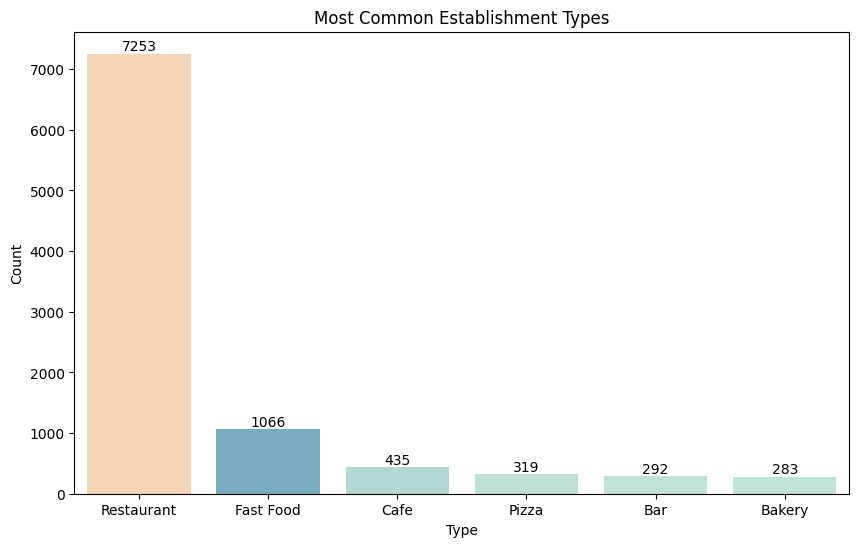

In [35]:
# Plotting the distribution of establishment types
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=top_rest_type, x='type', y='establishment_count', palette="icefire", hue='establishment_count', legend=False)

# Adding data labels for better readability
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}',          
                (p.get_x() + p.get_width() / 2,   
                 p.get_height()),                 
                ha='center', va='bottom')

plt.title('Most Common Establishment Types')
plt.xlabel('Type')
plt.ylabel('Count')
plt.show()

#### **Key Insight:**

The "Restaurant" category stands out significantly with 7,255 units. It is followed by "Fast Food" and "Cafes". Interestingly, even when combined, the second and third most common types do not reach half the total count of the "Restaurant" category, highlighting its market dominance.

### **4.2. Chain vs. Non-Chain Establishments**

Next, we investigate the proportion of chain establishments compared to independent ones.

C:\Users\lucas\AppData\Local\Temp\ipykernel_19672\2290379001.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Non-Chain', 'Chain', 'Undefined'])


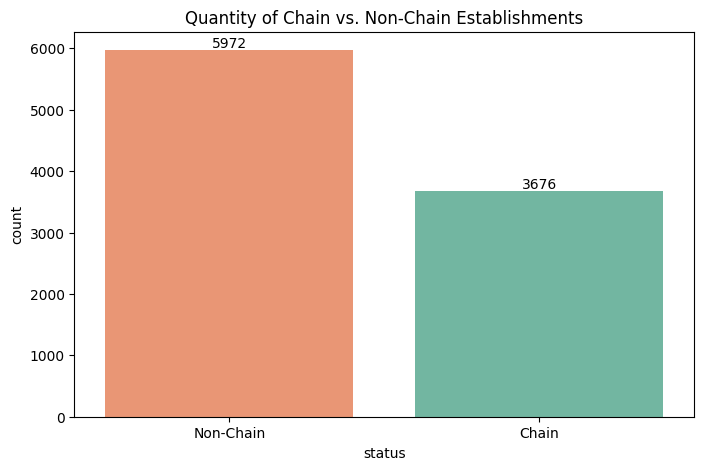

In [37]:
# Calculating the distribution of chains
chain_dist = rest_data['chain'].value_counts().reset_index()
chain_dist.columns = ['status', 'count']

# Visualization
plt.figure(figsize=(8, 5))
ax = sns.barplot(data=chain_dist, x='status', y='count', palette="Set2", hue='count', legend=False)

# Annotating bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}',           
                (p.get_x() + p.get_width() / 2,    
                 p.get_height()),                  
                ha='center', va='bottom',          
                fontsize=10, color='black')   

ax.set_xticklabels(['Non-Chain', 'Chain', 'Undefined'])
plt.title('Quantity of Chain vs. Non-Chain Establishments')
plt.show()

#### **Analysis:**

The dataset contains 5,972 independent establishments and 3,676 chains. While independent businesses are more numerous, the significant presence of chains warrants a deeper look—particularly into which categories, such as Fast Food, drive these numbers.

### **4.3. Identifying Typical Chain Establishments**

To determine which types of businesses are most commonly structured as chains, we filtered the data for chain == True and calculated the distribution across categories.

In [ ]:
# Filtering for chains and counting establishment types
chain_only = rest_data[rest_data['chain'] == True]
chain_counts = chain_only['object_type'].value_counts().reset_index()
chain_counts.columns = ['Establishment Type', 'Chain Count']

display(chain_counts)

,Establishment Type,Chain Count
0,Restaurant,2292
1,Fast Food,605
2,Bakery,283
3,Cafe,266
4,Pizza,153
5,Bar,77


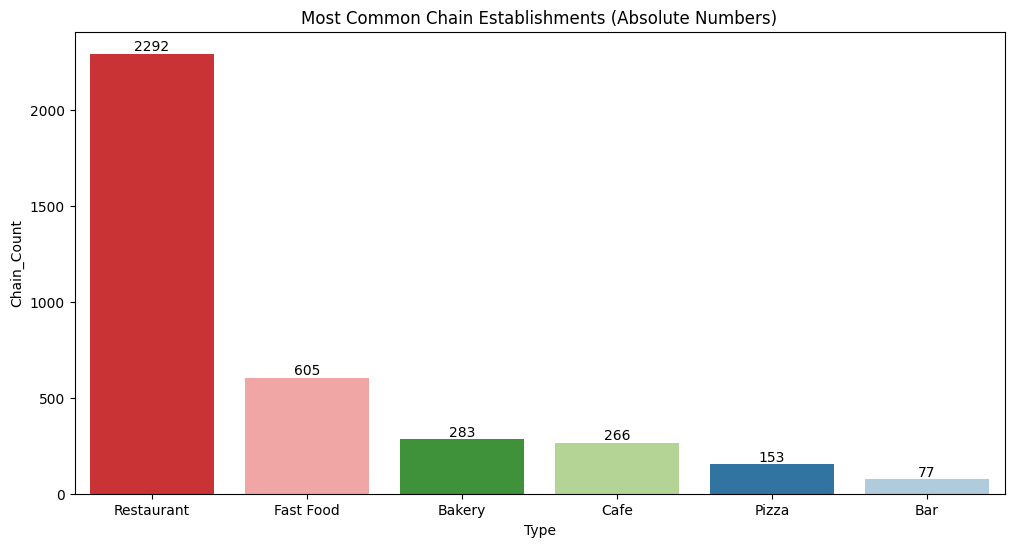

In [42]:
# Filtering for chains and calculating counts
chain_only = rest_data[rest_data['chain'] == True]
chain_counts = chain_only['object_type'].value_counts().reset_index()
chain_counts.columns = ['Type', 'Chain_Count']

# Visualization
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=chain_counts, x='Type', y='Chain_Count', palette="Paired", hue='Chain_Count', legend=False)

# Adding data labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}',           
                (p.get_x() + p.get_width() / 2,    
                 p.get_height()),                  
                ha='center', va='bottom',          
                fontsize=10, color='black')   

plt.title('Most Common Chain Establishments (Absolute Numbers)')
plt.show()

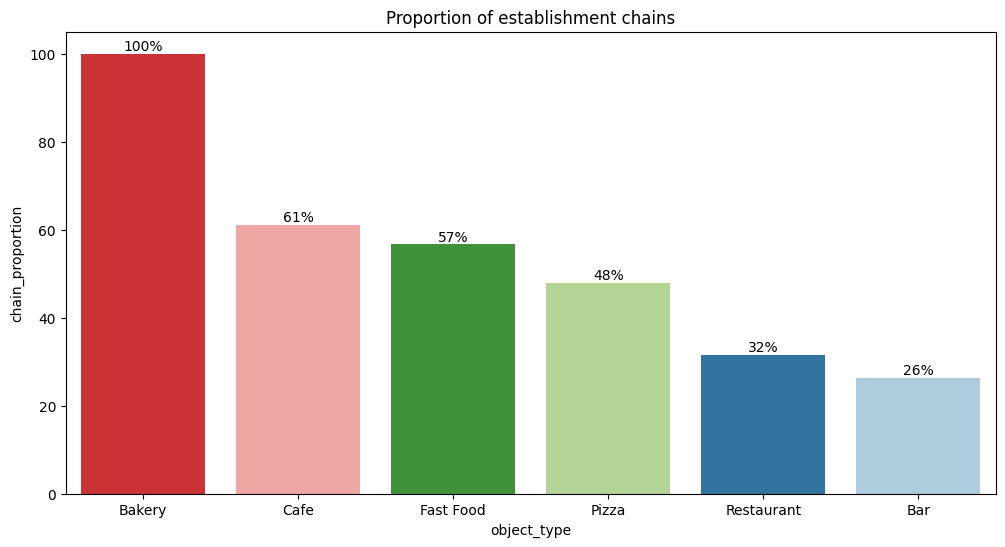

In [49]:
prop = rest_data.groupby('object_type')['chain'].mean().sort_values(ascending=False).reset_index(name='chain_proportion')
prop['chain_proportion'] = prop['chain_proportion'] * 100

# Visualization
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=prop, x='object_type', y='chain_proportion', palette="Paired", hue='chain_proportion', legend=False)

# Adding data labels
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}%',           
                (p.get_x() + p.get_width() / 2,    
                 p.get_height()),                  
                ha='center', va='bottom',          
                fontsize=10, color='black')   

plt.title('Proportion of establishment chains')
plt.show()

### **Key Insights & Disproportionality:**

While "Restaurants" have the highest absolute number of chains, a deeper look at the ratios reveals a different story:

Market Concentration: Only 31.6% of all restaurants in the dataset operate as chains, suggesting a market dominated by independent owners.

Segment Specialists: In contrast, Bakery and Cafe segments show the highest propensity for the chain model (100% and 61% respectively).

Fast Food Paradox: Interestingly, "Fast Food" — a segment traditionally associated with franchising — shows a moderate chain rate of 57% in this dataset, only slightly above half of the total.

### **4.4. Characterizing Chain Behavior: Scale vs. Capacity**

A key question in this industry is whether chains grow by opening many small locations or a few large ones. First, we examine the statistical distribution of seats within chain establishments.

In [52]:
# Statistical summary of seating capacity for chains
chain_only['number'].describe()

count    3676.000000
mean       39.694233
std        43.437212
min         1.000000
25%        13.000000
50%        25.000000
75%        44.000000
max       229.000000
Name: number, dtype: float64

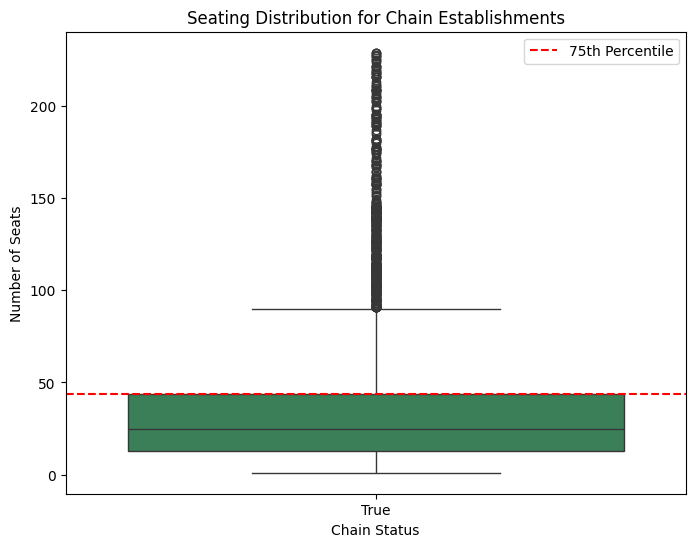

In [56]:
# Visualizing the distribution of seats in chains
plt.figure(figsize=(8, 6))
sns.boxplot(x="chain", y="number", data=chain_only, color='seagreen')

# Highlighting the 75th percentile
plt.axhline(np.percentile(chain_only['number'], 75), color='red', linestyle='--', label='75th Percentile')

plt.title('Seating Distribution for Chain Establishments')
plt.ylabel('Number of Seats')
plt.xlabel('Chain Status')
plt.legend()
plt.show()

**Conclusion:** 

The data suggests that chains typically favor a model of high-volume, smaller-capacity locations rather than a few massive venues.

### **4.5. Average Capacity by Establishment Type**

To further understand the market, we calculated the mean seating capacity for each category and visualized the variance using boxplots (excluding outliers for better clarity).

,object_type,number
5,Restaurant,48
1,Bar,44
3,Fast Food,31
4,Pizza,28
2,Cafe,25
0,Bakery,21


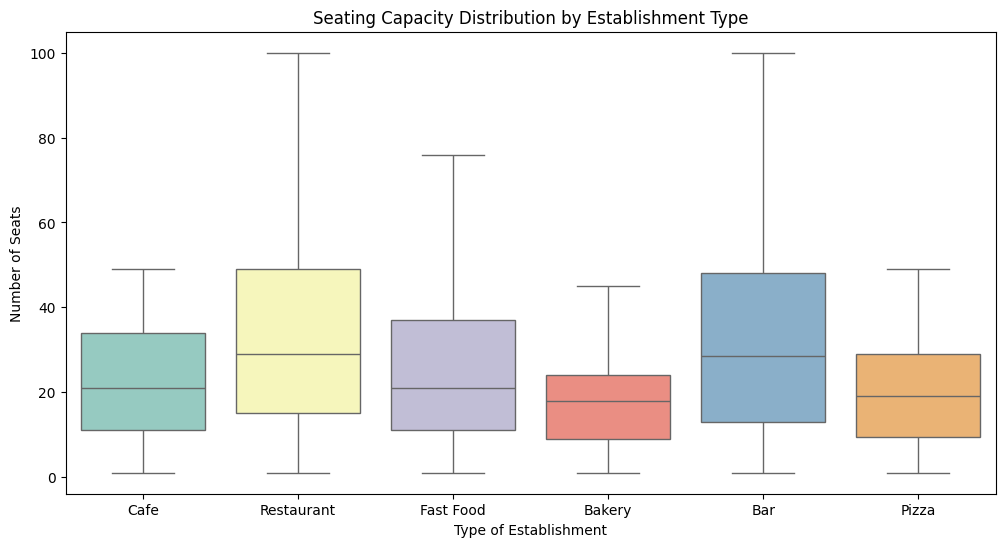

In [58]:
# Calculating mean seats per type
avg_seats = rest_data.groupby(['object_type'])['number'].mean().reset_index()
avg_seats['number'] = avg_seats['number'].astype(int)

# Displaying ranked averages
display(avg_seats.sort_values(by='number', ascending=False))

# Visualizing distributions across all types
plt.figure(figsize=(12, 6))
sns.boxplot(x="object_type", y="number", data=rest_data, showfliers=False, palette="Set3", hue='object_type', legend=False)

plt.title('Seating Capacity Distribution by Establishment Type')
plt.ylabel('Number of Seats')
plt.xlabel('Type of Establishment')
plt.show()

**Key Findings:**

The average capacity varies significantly across segments:

- Restaurants: 48 seats (Leading the segment)

- Bars: 44 seats

- Fast Food: 31 seats

- Pizza: 28 seats

- Cafes: 25 seats

- Bakeries: 21 seats

**Analysis:**

Full-service Restaurants and Bars maintain the highest average seating capacity. Conversely, Bakeries and Cafes operate as more intimate or "grab-and-go" venues, with the lowest average seat counts in the dataset.

### **5. Geospatial Analysis: Street Concentration**

#### 5.1. Feature Engineering: Extracting Street Names

The address column contains full American-style addresses (number, street name, and suffix). To analyze location density, we need to isolate the street names. We developed a custom function to strip house numbers and special characters, capturing the core street name along with its suffix (e.g., BLVD, ST, AVE).

In [59]:
# List of common American street suffixes
suffixes = ['BLVD', 'ST', 'AVE', 'RD', 'DR', 'WAY']

def get_street_name(address):
    # Cleaning special characters and splitting the string
    split_address = address.replace("#", "").replace("/", "").split()
    new_street = []
    
    for word in split_address:
        if word.isdigit():
            continue  # Skip house numbers
        new_street.append(word)
        if word.upper() in suffixes:
            break  # Stop at the street suffix
    
    return ' '.join(new_street)

# Creating the 'street' column
rest_data['street'] = rest_data['address'].apply(get_street_name)

In [60]:
rest_data.head()

,id,object_name,address,chain,object_type,number,street
0,11786,HABITAT COFFEE SHOP,3708 N EAGLE ROCK BLVD,False,Cafe,26,N EAGLE ROCK BLVD
1,11787,REILLY'S,100 WORLD WAY 120,False,Restaurant,9,WORLD WAY
2,11788,STREET CHURROS,6801 HOLLYWOOD BLVD 253,False,Fast Food,20,HOLLYWOOD BLVD
3,11789,TRINITI ECHO PARK,1814 W SUNSET BLVD,False,Restaurant,22,W SUNSET BLVD
4,11790,POLLEN,2100 ECHO PARK AVE,False,Restaurant,20,ECHO PARK AVE


### **5.2. Top 10 Streets by Restaurant Concentration**

We filtered the dataset to focus exclusively on the "Restaurant" category and identified the top 10 streets with the highest density of establishments.

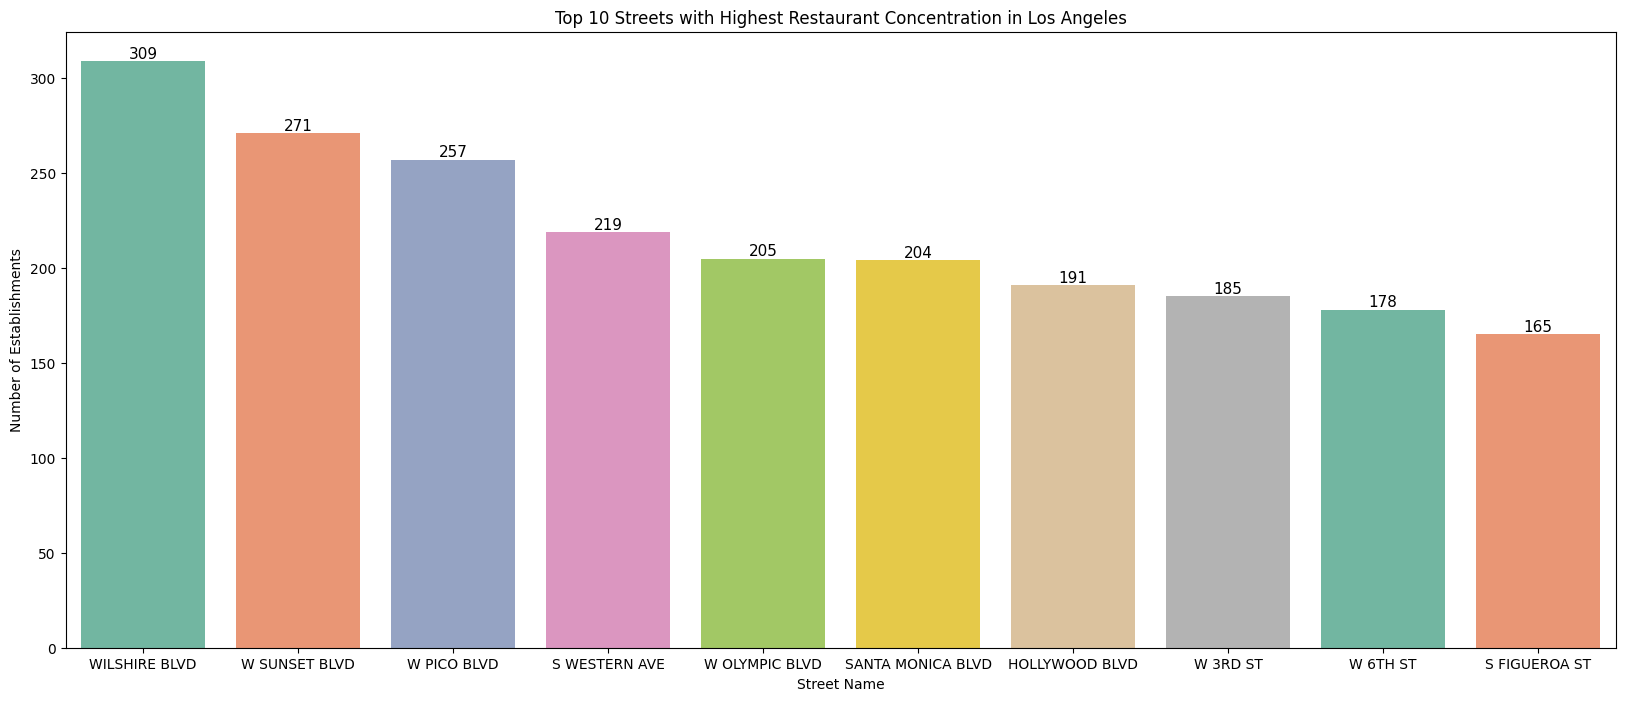

In [62]:
# Filtering for restaurants and identifying top 10 streets
restaurants_only = rest_data[rest_data['object_type'] == 'Restaurant']
top10_streets = restaurants_only['street'].value_counts().reset_index().head(10)
top10_streets.columns = ['Street', 'Count']

# Visualization
plt.figure(figsize=(20, 8))
ax = sns.barplot(data=top10_streets, x='Street', y='Count', palette='Set2', hue='Street', legend=False)

# Adding labels to bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}',          
                (p.get_x() + p.get_width() / 2,   
                 p.get_height()),                 
                ha='center', va='bottom',          
                fontsize=11)

plt.title('Top 10 Streets with Highest Restaurant Concentration in Los Angeles')
plt.ylabel('Number of Establishments')
plt.xlabel('Street Name')
plt.show()

**Location Insights & Business Context:**

The analysis reveals that restaurant density is heavily concentrated on major arterial roads:

- Wilshire Boulevard: Emerging as the leader, this is one of the most critical east-west arteries in Los Angeles, connecting Santa Monica to the Financial District. Its role as a transit hub makes it a prime location for the food industry.

- Sunset Boulevard: One of the most iconic streets globally, it is a mandatory route for tourists and residents alike, explaining the high volume of establishments.

**Strategic Conclusion:** 

These 10 streets represent the "beating heart" of the Los Angeles dining scene. For a new business venture, these areas offer high visibility and foot traffic, although they likely come with higher competition and real estate costs.

### **5.3. Analysis of Low-Density Streets**

We also investigated streets with minimal restaurant presence to understand the overall distribution across the city.

In [64]:
# Identifying streets with only one restaurant
street_counts = rest_data['street'].value_counts()
single_rest_streets = street_counts[street_counts == 1]

print(f"Total streets with at least one restaurant: {len(street_counts)}")
print(f"Streets with only one restaurant: {len(single_rest_streets)}")

Total streets with at least one restaurant: 817
Streets with only one restaurant: 390


**Findings:**

Out of 817 streets with restaurants, 390 (approximately 48%) contain only a single establishment. This indicates that while there are massive hubs like Wilshire Blvd, nearly half of the city's culinary landscape is composed of isolated, independent locations.

### **5.4. High-Density Streets vs. Seating Capacity**

Does a high concentration of restaurants imply larger venues? We analyzed streets with more than 6 establishments (the 75th percentile) to find trends in seating capacity.

In [82]:
# Filtering for high-density streets (> 6 restaurants)
high_density_streets = street_counts[street_counts > 6].index
many_restaurants_df = rest_data[rest_data['street'].isin(high_density_streets)]

average_seats_per_street = many_restaurants_df.groupby('street')['number'].mean().reset_index()
average_seats_per_street.columns = ['Street', 'number']


# Comparing restaurant count vs. average seating capacity
street_comparison = pd.merge(top10_streets, average_seats_per_street, on='Street', how='left')

C:\Users\lucas\AppData\Local\Temp\ipykernel_19672\1216775487.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(labels=street_comparison['Street'], rotation=45)


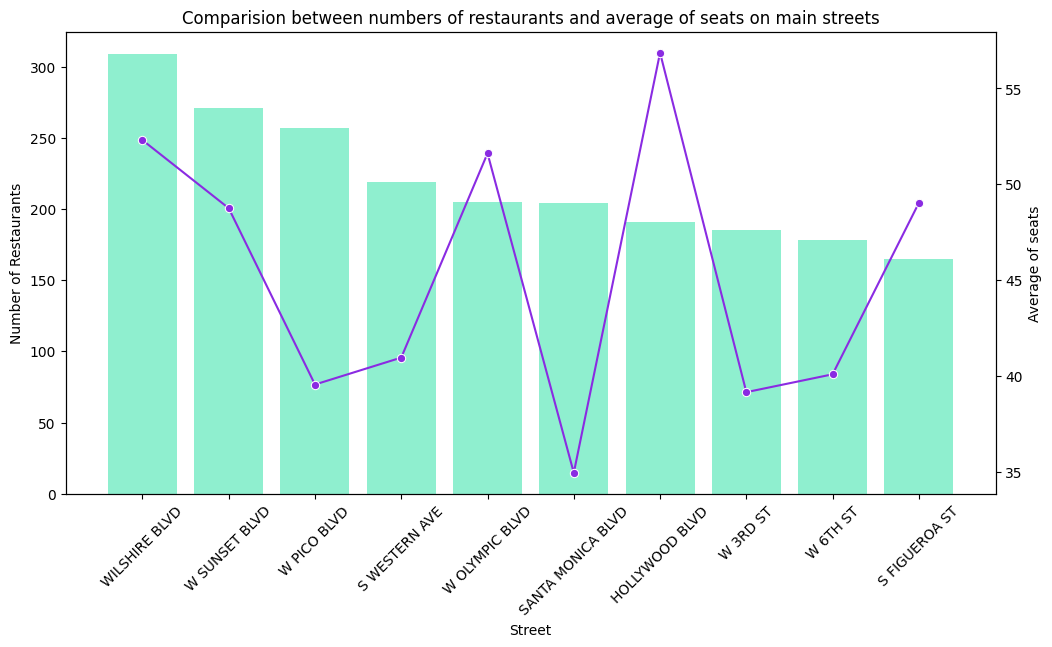

In [90]:
fig, ax1 = plt.subplots(figsize=(12, 6))

from matplotlib.ticker import FixedLocator


# Plotting barplot

sns.barplot(data=street_comparison, x='Street', y='Count', color='aquamarine', ax=ax1)

ax1.set_ylabel('Number of Restaurants')

ax1.set_xlabel('Street')

ax1.set_xticklabels(labels=street_comparison['Street'], rotation=45)

# Adicionando um segundo eixo y para a média de assentos

ax2 = ax1.twinx()

sns.lineplot(data=street_comparison, x='Street', y='number', color='blueviolet', marker='o', ax=ax2)

ax2.set_ylabel('Average of seats')



# Título e exibição

plt.title('Comparision between numbers of restaurants and average of seats on main streets')

plt.show()

**Key Observation:**

There is no direct correlation between restaurant density and establishment size. For instance, the street with the highest concentration of restaurants has an average capacity of 50 seats, nearly identical to streets with half the restaurant count. This suggests that establishment type (e.g., fine dining vs. small cafes) is a stronger predictor of capacity than location density.

**6. Final Conclusion and Strategic Recommendation**

Based on the analysis of the Los Angeles food service market, the following insights were derived for the launch of the Robot-Waiter Cafe:

- The Franchise Challenge: Chains dominate the Cafe and Bakery sectors (61% and 100% respectively). For a new independent venture, competing on price with these giants is a high-risk strategy.

- The "Restaurant" Opportunity: The Restaurant sector has a much lower chain penetration (31.6%), offering a more level playing field for unique, innovation-driven concepts.

- Optimal Capacity: A capacity of approximately 50 seats is recommended. This aligns with the average for high-traffic areas and allows the business to scale while maintaining the "tech-attraction" atmosphere.

- Location Strategy: We recommend a high-traffic arterial road (e.g., Wilshire or Sunset Blvd). While competition is higher, the robot-waiter innovation acts as a powerful differentiator, turning the cafe into a tourist and local destination rather than just a dining spot.

**Final Verdict:** The project is viable, provided that the marketing leverages the "robot innovation" to mitigate the competitive pressure from established chains.